In [86]:
import pandas as pd
from seaborn import color_palette

import snman_abm
import snman
import random
import os
import matplotlib.pyplot as plt
import copy
import importlib
import seaborn as sns

PROJECT = '_main'
data_directory = os.path.join('C:',os.sep,'Users','shiry', 'snman_sgProject')
export_path = os.path.join(data_directory, 'outputs', PROJECT)
inputs_path = os.path.join(data_directory, 'inputs', PROJECT)

G = snman.io.load_street_graph(
    edges_path=os.path.join(export_path, 'G_edges.gpkg'),
    nodes_path=os.path.join(export_path, 'G_nodes.gpkg'),
    crs=3414
)

nodes = list(G.nodes())

## Run the Model for Before and After Network Reallocation

In [87]:
template_before = snman_abm.Network(scenario="before", n=0, od_pairs=[])
template_after = snman_abm.Network(scenario="after", n=0, od_pairs=[])

base_car_before = copy.deepcopy(template_before.car_graph)
base_car_after = copy.deepcopy(template_after.car_graph)

base_bike_before = copy.deepcopy(template_before.bike_graph)
base_bike_after = copy.deepcopy(template_after.bike_graph)

In [88]:
results = []
trip_lengths = []

n_runs = 100
n_agents = 1000

for run in range(n_runs):
    od_pairs = []
    while len(od_pairs) < n_agents:
        origin = random.choice(nodes)
        destination = random.choice(nodes)

        if origin == destination:
            continue

        od_pairs.append((origin, destination))

    model_before = snman_abm.Network(
        scenario="before",
        n=n_agents,
        od_pairs=od_pairs,
        car_graph=copy.deepcopy(base_car_before),
        bike_graph=copy.deepcopy(base_bike_before),
    )

    model_after = snman_abm.Network(
        scenario="after",
        n=n_agents,
        od_pairs=od_pairs,
        car_graph=copy.deepcopy(base_car_after),
        bike_graph=copy.deepcopy(base_bike_after),
    )

    max_steps = int((model_before.end_time - model_before.start_time) / model_before.step_time)

    steps = 0
    while any(not agent.has_traveled for agent in model_before.schedule.agents) and steps < max_steps:
        model_before.step()
        steps += 1

    max_steps = int((model_after.end_time - model_after.start_time) / model_after.step_time)

    steps = 0
    while any(not agent.has_traveled for agent in model_after.schedule.agents) and steps < max_steps:
        model_after.step()
        steps += 1

    df_before = model_before.get_journeys()
    df_after = model_after.get_journeys()

    trip_lengths.extend((df_before["distance_m"] / 1000).tolist())

    before_counts = df_before["mode"].value_counts(normalize=True)
    after_counts = df_after["mode"].value_counts(normalize=True)

    bike_before = before_counts.get("bike", 0)
    bike_after = after_counts.get("bike", 0)

    results.append({
        "run": run + 1,
        "bike_before": bike_before,
        "bike_after": bike_after,
        "change": bike_after - bike_before,
    })

    print(f"Run {run+1}/{n_runs} done. Bike before: {bike_before:.3f}, after: {bike_after:.3f}")

Run 1/100 done. Bike before: 0.145, after: 0.205
Run 2/100 done. Bike before: 0.151, after: 0.204
Run 3/100 done. Bike before: 0.141, after: 0.211
Run 4/100 done. Bike before: 0.154, after: 0.205
Run 5/100 done. Bike before: 0.149, after: 0.209
Run 6/100 done. Bike before: 0.146, after: 0.206
Run 7/100 done. Bike before: 0.140, after: 0.181
Run 8/100 done. Bike before: 0.181, after: 0.215
Run 9/100 done. Bike before: 0.150, after: 0.220
Run 10/100 done. Bike before: 0.141, after: 0.199
Run 11/100 done. Bike before: 0.140, after: 0.182
Run 12/100 done. Bike before: 0.136, after: 0.200
Run 13/100 done. Bike before: 0.159, after: 0.213
Run 14/100 done. Bike before: 0.148, after: 0.197
Run 15/100 done. Bike before: 0.171, after: 0.220
Run 16/100 done. Bike before: 0.161, after: 0.224
Run 17/100 done. Bike before: 0.148, after: 0.180
Run 18/100 done. Bike before: 0.159, after: 0.218
Run 19/100 done. Bike before: 0.143, after: 0.206
Run 20/100 done. Bike before: 0.149, after: 0.200
Run 21/10

## Trip Details

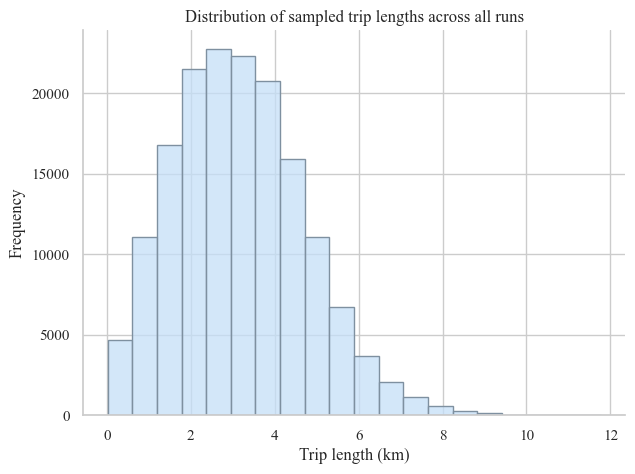

In [103]:
plt.figure(figsize=(7, 5))
sns.histplot(trip_lengths, bins=20, stat="frequency", color="#C5DFF8", edgecolor="#7E90A0")
sns.set_theme(style="whitegrid", font="times new roman")
sns.despine()

plt.xlabel("Trip length (km)")
plt.ylabel("Frequency")
plt.title("Distribution of sampled trip lengths across all runs")
plt.show()

## Mode Share Analysis

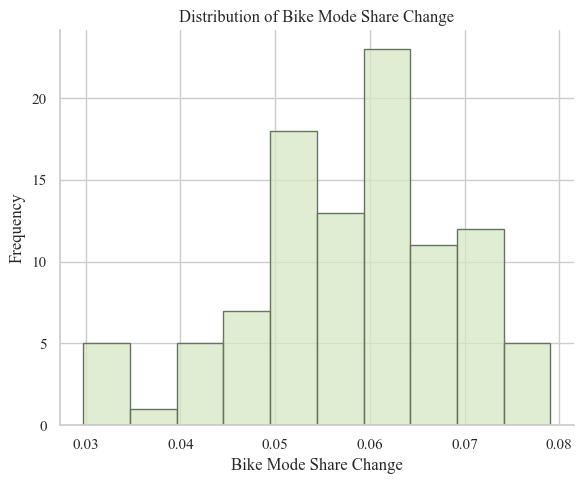

In [100]:
# plot histogram of mode share change across all the runs
results_df = pd.DataFrame(results)
plt.figure(figsize=(6, 5))
sns.set_theme(style="whitegrid", font="times new roman")
sns.histplot(results_df["change"], bins=10, edgecolor="#657361", color="#D7E8C3")
sns.despine()


plt.xlabel("Bike Mode Share Change")
plt.ylabel("Frequency")
plt.title("Distribution of Bike Mode Share Change")
plt.tight_layout()
plt.show()

In [91]:
mean_before = results_df["bike_before"].mean()
mean_after = results_df["bike_after"].mean()
std_before = results_df["bike_before"].std()
std_after = results_df["bike_after"].std()

print("Mean change:", results_df["change"].mean())
print("Std dev:", results_df["change"].std())
print("Min change:", results_df["change"].min())
print("Max change:", results_df["change"].max())

Mean change: 0.05792250681496797
Std dev: 0.010737293976096742
Min change: 0.02974289206987657
Max change: 0.07905287150474175


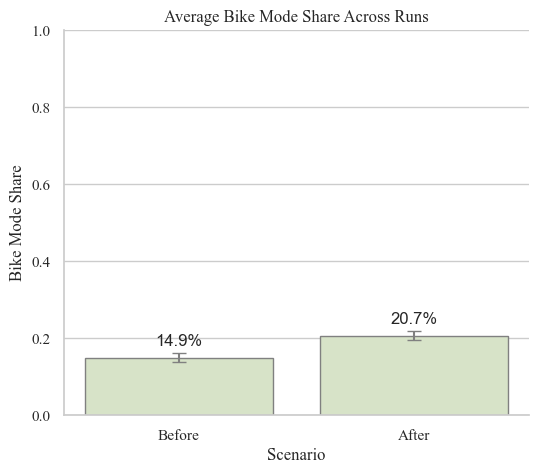

In [112]:
# plot avg bike mode share before and after, across runs
df = pd.DataFrame({
    "Scenario": ["Before", "After"],
    "Mean": [mean_before, mean_after],
    "Std": [std_before, std_after]
})

plt.figure(figsize=(6, 5))
ax = sns.barplot(data=df, x="Scenario", y="Mean", color="#D7E8C3", edgecolor="grey")
sns.set_theme(style="whitegrid")

plt.errorbar(
    x=[0, 1],
    y=df["Mean"],
    yerr=df["Std"],
    fmt="none",
    c="grey",
    capsize=5
)

plt.text(0, mean_before + 0.03, f"{mean_before*100:.1f}%", ha="center")
plt.text(1, mean_after + 0.03, f"{mean_after*100:.1f}%", ha="center")
plt.ylabel("Bike Mode Share")
plt.title("Average Bike Mode Share Across Runs")
plt.ylim(0, 1)
sns.despine()
plt.show()

mode           Bike (%)  Car (%)
distance_band                   
0-1                80.6     19.4
1-2                36.0     64.0
2-3                 2.2     97.8
3-5                 3.7     96.3
5+                  3.6     96.4


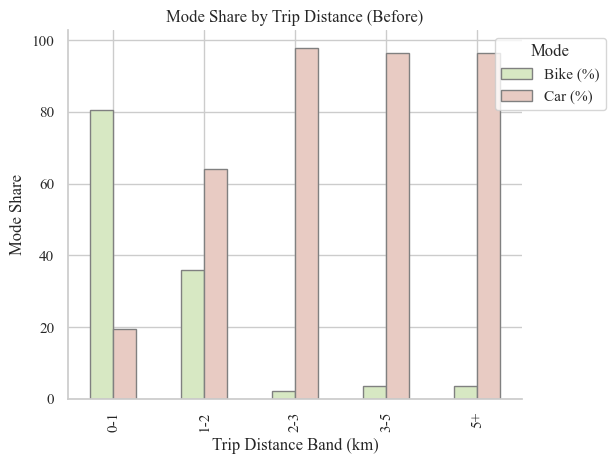

In [118]:
bins = [0, 1, 2, 3, 5, 10]  # km
labels = ["0-1", "1-2", "2-3", "3-5", "5+"]

df_before["distance_km"] = df_before["distance_m"] / 1000
df_before["distance_band"] = pd.cut(df_before["distance_km"], bins=bins, labels=labels)

mode_by_dist_before = pd.crosstab(
    df_before["distance_band"],
    df_before["mode"],
    normalize="index"
)

mode_by_dist_before = (mode_by_dist_before * 100).round(1)
mode_by_dist_before = mode_by_dist_before.rename(columns={
    "bike": "Bike (%)",
    "car": "Car (%)"
})

print(mode_by_dist_before)

sns.set_theme(style="whitegrid", font="times new roman")
mode_by_dist_before.plot(kind="bar", color=["#D7E8C3", "#E8CBC3"], edgecolor="grey")
plt.xlabel("Trip Distance Band (km)")
plt.ylabel("Mode Share")
plt.title("Mode Share by Trip Distance (Before)")
plt.legend(title="Mode", bbox_to_anchor=(1.2, 1), loc="upper right")
plt.tight_layout()
sns.despine()
plt.show()

mode           Bike (%)  Car (%)
distance_band                   
0-1                90.7      9.3
1-2                71.8     28.2
2-3                 7.5     92.5
3-5                 2.9     97.1
5+                  1.6     98.4


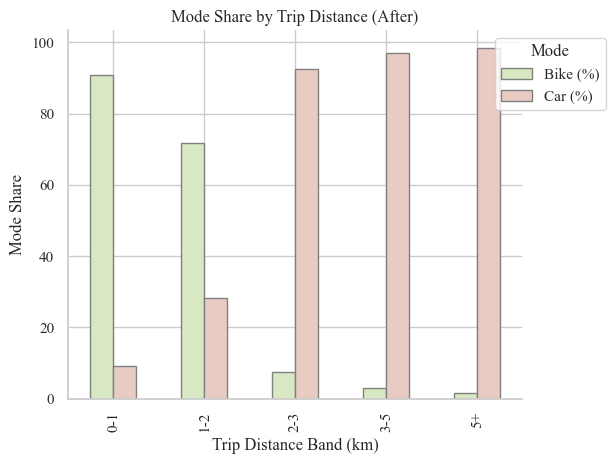

In [129]:
bins = [0, 1, 2, 3, 5, 10]  # km
labels = ["0-1", "1-2", "2-3", "3-5", "5+"]

mode_by_dist_after = pd.crosstab(
    df_after["distance_band"],
    df_after["mode"],
    normalize="index"
)

mode_by_dist_after = (mode_by_dist_after * 100).round(1)
mode_by_dist_after = mode_by_dist_after.rename(columns={
    "bike": "Bike (%)",
    "car": "Car (%)"
})

print(mode_by_dist_after)

sns.set_theme(style="whitegrid", font="times new roman")
mode_by_dist_after.plot(kind="bar", color=["#D7E8C3", "#E8CBC3"], edgecolor="grey")
plt.xlabel("Trip Distance Band (km)")
plt.ylabel("Mode Share")
plt.title("Mode Share by Trip Distance (After)")
plt.legend(title="Mode", bbox_to_anchor=(1.2, 1), loc="upper right")
plt.tight_layout()
sns.despine()
plt.show()

## Congestion and Traffic Flow

In [95]:
network_stats_before = pd.DataFrame(model_before.network_stats)
network_stats_after = pd.DataFrame(model_after.network_stats)

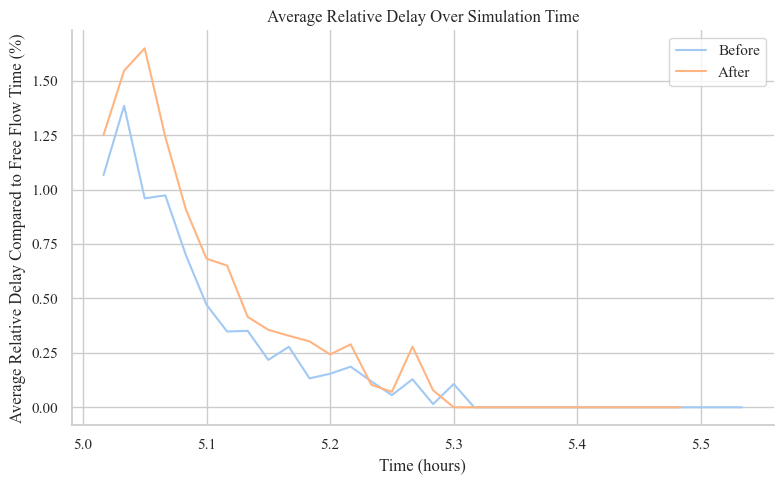

In [128]:
plt.figure(figsize=(8, 5))
plt.plot(network_stats_before["time"], network_stats_before["average_relative_delay"] * 100, label="Before")
plt.plot(network_stats_after["time"], network_stats_after["average_relative_delay"] * 100, label="After")

sns.set_theme(style="whitegrid", palette="pastel", font="times new roman")
sns.despine()
plt.xlabel("Time (hours)")
plt.ylabel("Average Relative Delay Compared to Free Flow Time (%)")
plt.title("Average Relative Delay Over Simulation Time")
plt.legend()
plt.tight_layout()
plt.show()